In [8]:
# ============================================================
# UBER TRIP FORECASTING – NEXT 14 DAYS (SINGLE CELL PIPELINE)
# ============================================================

# -------------------------------
# 1. Import required libraries
# -------------------------------
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# -------------------------------
# 2. Load dataset and set datetime index
# -------------------------------
df = pd.read_csv("../DATASET/Uber-Jan-Feb-FOIL.csv")

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df = df.sort_index()

# -------------------------------
# 3. Feature Engineering
# -------------------------------

# Base features
df_fe = df[['trips', 'active_vehicles']].copy()

# Time-based features
df_fe['day'] = df_fe.index.day
df_fe['day_of_week'] = df_fe.index.dayofweek
df_fe['week_of_year'] = df_fe.index.isocalendar().week.astype(int)
df_fe['month'] = df_fe.index.month
df_fe['is_weekend'] = df_fe['day_of_week'].isin([5, 6]).astype(int)

# Lag features
df_fe['trips_lag_1'] = df_fe['trips'].shift(1)
df_fe['trips_lag_7'] = df_fe['trips'].shift(7)
df_fe['trips_lag_14'] = df_fe['trips'].shift(14)

# Rolling features
df_fe['trips_roll_7'] = df_fe['trips'].rolling(7).mean()
df_fe['trips_roll_14'] = df_fe['trips'].rolling(14).mean()

# Remove rows with missing values (created by lag/rolling)
df_fe_clean = df_fe.dropna()

# -------------------------------
# 4. Prepare training data
# -------------------------------
X = df_fe_clean.drop(columns=['trips'])
y = df_fe_clean['trips']

# -------------------------------
# 5. Train Random Forest model
# -------------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X, y)

# -------------------------------
# 6. Create future dates (next 14 days)
# -------------------------------
last_date = df_fe_clean.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=14,
    freq='D'
)

# -------------------------------
# 7. Create future feature dataframe
# -------------------------------
last_row = df_fe_clean.iloc[-1]
future_df = pd.DataFrame(index=future_dates)

# Time features for future
future_df['day'] = future_df.index.day
future_df['day_of_week'] = future_df.index.dayofweek
future_df['week_of_year'] = future_df.index.isocalendar().week.astype(int)
future_df['month'] = future_df.index.month
future_df['is_weekend'] = future_df['day_of_week'].isin([5, 6]).astype(int)

# Use last known values for supply & lag features
future_df['active_vehicles'] = last_row['active_vehicles']
future_df['trips_lag_1'] = last_row['trips']
future_df['trips_lag_7'] = last_row['trips_lag_7']
future_df['trips_lag_14'] = last_row['trips_lag_14']
future_df['trips_roll_7'] = last_row['trips_roll_7']
future_df['trips_roll_14'] = last_row['trips_roll_14']

# -------------------------------
# 8. ALIGN FEATURE ORDER (CRITICAL STEP)
# -------------------------------
# Ensure future features match training features exactly
future_df = future_df[X.columns.tolist()]

# -------------------------------
# 9. Forecast next 14 days
# -------------------------------
future_predictions = rf_model.predict(future_df)

forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_trips": future_predictions.astype(int)
})

# -------------------------------
# 10. Final Output
# -------------------------------
print("14-Day Uber Trip Forecast Generated Successfully")
forecast_df


14-Day Uber Trip Forecast Generated Successfully


,date,predicted_trips
0,2015-03-01,7509
1,2015-03-02,7234
2,2015-03-03,7261
3,2015-03-04,7262
4,2015-03-05,7338
5,2015-03-06,7508
6,2015-03-07,7525
7,2015-03-08,7519
8,2015-03-09,7260
9,2015-03-10,7285


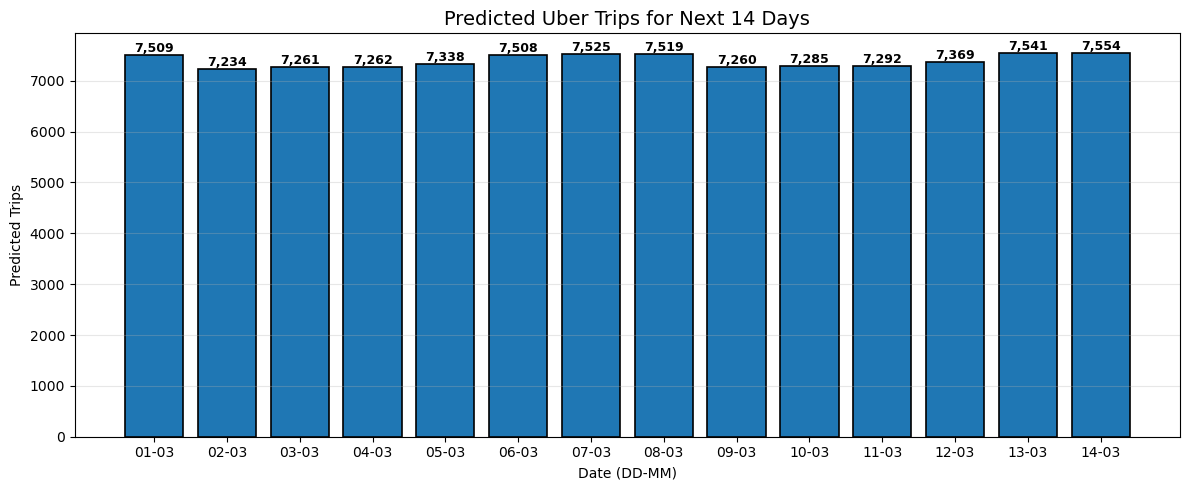

In [10]:
import matplotlib.pyplot as plt

# Format dates as DD-MM (no year)
dates = forecast_df['date'].dt.strftime('%d-%m')
predicted_trips = forecast_df['predicted_trips']

plt.figure(figsize=(12, 5))

bars = plt.bar(
    dates,
    predicted_trips,
    edgecolor='black',
    linewidth=1.2
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.title("Predicted Uber Trips for Next 14 Days", fontsize=14)
plt.xlabel("Date (DD-MM)")
plt.ylabel("Predicted Trips")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
